<a href="https://colab.research.google.com/github/touhid0503/Machine-Learning-Full-Course-with-Scikit-Learn/blob/main/04_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression using Scikit-Learn

In [136]:
from sklearn.linear_model import LinearRegression

In [137]:
model=LinearRegression()

In [138]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianHQ/notebooks/refs/heads/main/machine-learning-with-python-zero-to-gbms/lesson-1-linear-regression-with-scikit-learn/medical-charges.csv'

In [139]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7eeab442b9b0>)

In [140]:
import pandas as pd

In [141]:
medical_df = pd.read_csv('medical.csv')

In [142]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges
296,19,male,27.700,0,yes,southwest,16297.84600
146,46,male,30.495,3,yes,northwest,40720.55105
648,18,male,28.500,0,no,northeast,1712.22700
271,50,male,34.200,2,yes,southwest,42856.83800
856,48,female,33.110,0,yes,southeast,40974.16490


In [143]:
medical_df.shape

(1338, 7)

In [144]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [145]:
non_smoker_df.sample(5)

,age,sex,bmi,children,smoker,region,charges
979,36,female,29.920,0,no,southeast,4889.03680
1270,26,male,33.915,1,no,northwest,3292.52985
521,32,female,44.220,0,no,southeast,3994.17780
735,49,female,34.770,1,no,northwest,9583.89330
1133,52,female,18.335,0,no,northwest,9991.03765


In [146]:
non_smoker_df.shape

(1064, 7)

In [147]:
import numpy as np

In [148]:
def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions)**2))

In [149]:
import matplotlib.pyplot as plt

#Linear Regression using Multiple Features


In [150]:
inputs, targets = non_smoker_df[['age','bmi']], non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


In [151]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

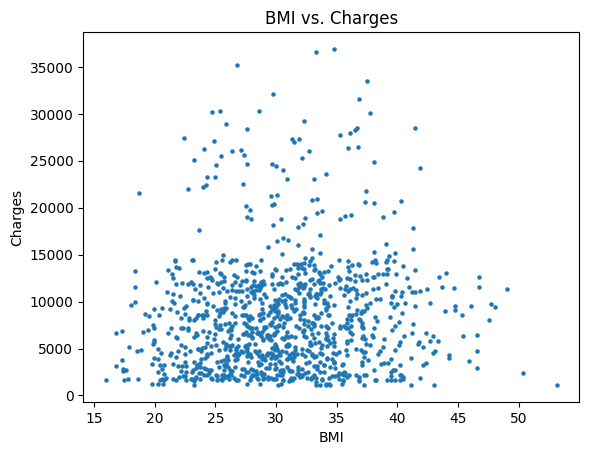

In [152]:
plt.scatter(non_smoker_df['bmi'], non_smoker_df['charges'], s=5)
plt.title('BMI vs. Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

In [153]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [154]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [155]:
import seaborn as sns

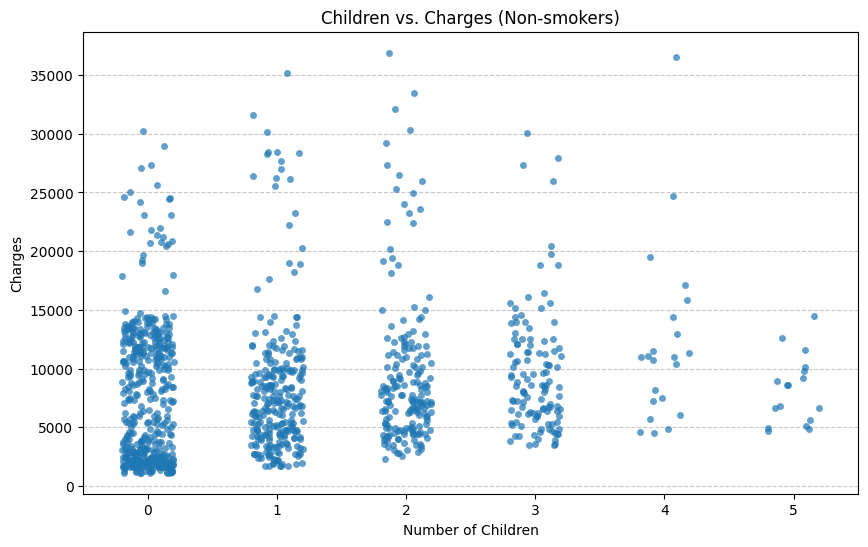

In [156]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='children', y='charges', data=non_smoker_df, jitter=0.2, alpha=0.7, s=5)
plt.title('Children vs. Charges (Non-smokers)')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [157]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


In [158]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [159]:
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


#Using Categorical Features for Machine Learning


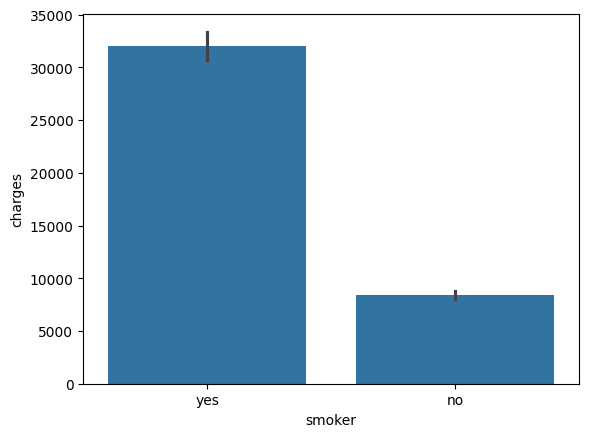

In [160]:
sns.barplot(data=medical_df, x='smoker', y='charges');

In [161]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [162]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
462,62,female,38.095,2,no,northeast,15230.32405,0
541,20,female,31.790,2,no,southeast,3056.38810,0
1076,47,female,32.000,1,no,southwest,8551.34700,0
463,56,male,25.935,0,no,northeast,11165.41765,0


In [163]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [164]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


<Axes: xlabel='sex', ylabel='charges'>

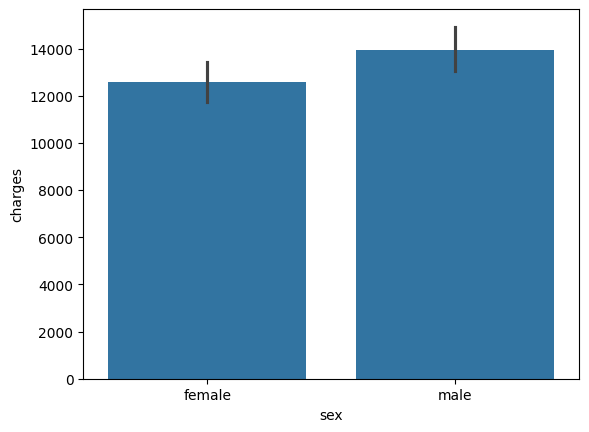

In [165]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [166]:
sex_codes = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [167]:
medical_df.sample(5)

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
1143,39,male,32.340,2,no,southeast,6338.07560,0,1
290,28,female,33.400,0,no,southwest,3172.01800,0,0
895,61,female,44.000,0,no,southwest,13063.88300,0,0
477,25,male,35.625,0,no,northwest,2534.39375,0,1
1086,55,male,28.975,0,no,northeast,10796.35025,0,1


In [168]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [169]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


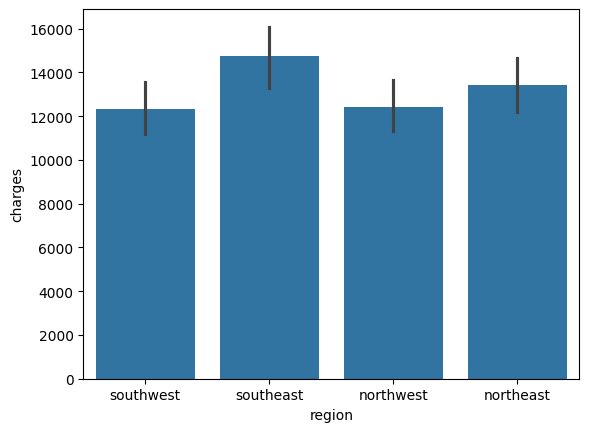

In [170]:
sns.barplot(data=medical_df, x='region', y='charges');

In [171]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()

In [172]:
one_hot = enc.fit_transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [173]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [174]:
one_hot.shape

(1338, 4)

In [175]:
medical_df.shape

(1338, 13)

In [176]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [177]:
medical_df.charges.corr(medical_df.northeast)

np.float64(0.006348771280156089)

In [178]:
medical_df.charges.corr(medical_df.northwest)

np.float64(-0.03990486404043802)

In [179]:
medical_df.charges.corr(medical_df.southeast)

np.float64(0.07398155156575982)

In [180]:
medical_df.charges.corr(medical_df.southwest)

np.float64(-0.04321002899168478)